# <font color='#433878'> Изучение рынка заведений общественного питания Москвы </font>


- Автор: Гусев Александр Олегович

---

## <font color='#7E60BF'> Цели и задачи проекта </font>

Цель проекта:

1. Провести исследовательский анализ рынка заведений общественного питания Москвы. 
2. Проанализировать информацию по заведениям Москвы на момент лета 2022 года. Выявить наиболее подходящие места под новое заведение.

---

## <font color='#7E60BF'> Описание данных </font>

<font color='#E4B1F0'> Данные состоят из двух датасетов: </font>

- `rest_info.csv` — содержит информацию о заведениях общественного питания;
- `rest_price.csv` —  содержит информацию о среднем чеке в заведениях общественного питания.

<font color='#E4B1F0'> Описание датасета `rest_info.csv` </font>

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- `seats` — количество посадочных мест.

<font color='#E4B1F0'> Описание датасета `rest_price.csv` </font>

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» ;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино».

---

## <font color='#7E60BF'> Содержимое проекта </font>

- Описание данных
- Загрузка данных и знакомство с ними
- Предобработка данных
- Исследовательский анализ данных

---

### <font color='#7E60BF'> Загрузка данных и знакомство с ними </font>

- Предварительно загрузим необходимые библиотеки для работы - pandas, matplotlib, seaborn, а также phik - для работы с таблицами, построения визуализаций, подсчета корреляции. Загрузим данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. 

In [1]:
# Установка библиотеки phik
!pip install phik

     |████████████████████████████████| 686 kB 1.2 MB/s eta 0:00:01


In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import numpy as np

In [3]:
# Выгружаем данные в переменные rest_info_df и rest_price_df
rest_info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` - выведем первые строки методом `head()`, и информацию о датафрейме - `info()`.

In [4]:
# Выводим первые строки датафрейма на экран
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датасете
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


После первичного анализа датасета `rest_info.csv` можно сделать следующие выводы:

Датасет `rest_info.csv` содержит 8 столбцов и 8406 строк, с информацией о заведениях общественного питания Москвы.

- названия столбцов имеют подходящий формат для работы и не требуют преобразований;
- значения столбцов `id`, `name`, `category`, `address`, `district`, `hours` - имеют тип данных `object` и содержат общую информацию о заведениях - наименование, расположение, категорию заведения, часы работы и уникальный id;
- столбцы `hours`, `seats` содержат пропуски, возможно пропуски в виде значений индикаторов встретятся и в других столбцах.

Общий вывод - данные в датасете соответствуют описанию, однако требуют дополнительной работы с пропусками и проверкой на дубликаты.

Также для датасета `rest_price.csv` - выведем первые строки методом `head()`, и информацию о датафрейме - `info()`.

In [6]:
# Выводим первые строки датафрейма на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датасете
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


После первичного анализа датасета `rest_price.csv` можно сделать следующие выводы:

Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, с информацией о среднем чеке в заведениях общественного питания.

- названия столбцов имеют подходящий формат для работы и не требуют преобразований;
- значения столбцов `id`, `price`, `avg_bill` - имеют тип данных `object` и содержат информацию об уникальном id заведения, категории цен и средние диапазоны сумм заказов;
- столбцы `middle_avg_bill`, `middle_coffee_cup` имеют средние значения по чекам и стоимости чашки кофе;
- все столбцы, кроме `id`, содержат пропуски в большей или меньшей степени, в дальнейшем потребуется детальный анализ природы этих пропусков.

Общий вывод - данные в датасете соответствуют описанию, присутствует большое количество пропусков, что нужно будет учесть при дальнейшем анализе.

### <font color='#7E60BF'> **Промежуточный вывод** </font>

На данном этапе были загружены и проанализированы два датасета: `rest_info.csv` и `rest_price.csv`. Они содержат данные о заведениях общественного питания Москвы и их характеристиках.

- Объем данных:

Датасет `rest_info.csv` включает 8406 строк и 9 столбцов.
Датасет `rest_price.csv` содержит 4058 строк и 5 столбцов.
- Соответствие данных описанию:

Данные соответствуют предоставленному описанию: в `rest_info.csv` представлена информация о заведениях (категория, адрес, часы работы, рейтинг, вместимость и др.), а в `rest_price.csv` — о ценах и среднем чеке.
Формат названий столбцов корректный и не требует изменений.
- Пропуски:

В `rest_info.csv` пропуски наблюдаются в столбцах `hours` (данные о времени работы) и `seats` (данные о количестве мест).
В `rest_price.csv` пропуски есть в столбцах `price`, `avg_bill`, `middle_avg_bill` и особенно много в `middle_coffee_cup`.
Пропуски требуют анализа, чтобы понять их природу и выбрать подходящий способ обработки.
- Типы данных:

Типы данных корректны.
- Другие особенности:

В обоих датасетах столбцы `id` позволяют связать данные, что пригодится для объединения таблиц.
Необходимо проверить данные на наличие дубликатов, так как это может повлиять на дальнейший анализ.
Поля с текстовыми значениями (например, `hours` и `avg_bill`) требуют предварительной обработки для стандартизации и извлечения полезной информации.
Общий вывод: предоставленные данные имеют подходящий формат и соответствуют описанию. Однако, из-за наличия пропусков, некорректных типов данных в некоторых столбцах и потенциальных дубликатов, необходимо уделить внимание их предобработке.

In [8]:
# Для удобной работы объединим датасеты в один общий
merged_data = pd.merge(rest_info_df, rest_price_df, on="id", how="left")

## <font color='#7E60BF'> Предобработка данных </font>

In [9]:
# Выведем информацию о новом датасете, проверим корректность типов данных
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
merged_data.head(100)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,62fc06f5aa2348e7a630e24ae8b4bd5c,Додо Пицца,пиццерия,"Москва, Дубнинская улица, 50",Северный административный округ,"ежедневно, 09:00–23:00",4.3,1,50.0,NaN,Средний счёт:349 ₽,349.0,NaN
96,c62c5d5a6d734a748a65fc8f928181df,CofeFest,кофейня,"Москва, улица Пришвина, 8",Северо-Восточный административный округ,пн-пт 08:00–19:00,4.3,1,NaN,NaN,NaN,NaN,NaN
97,670b0b0cf7f449078be63932ee9f2139,Жигулевское,"бар,паб","Москва, Бибиревская улица, 7к2",Северо-Восточный административный округ,"пн-чт 14:00–00:00; пт,сб 14:00–02:00; вс 14:00...",4.5,0,NaN,средние,Цена бокала пива:90–230 ₽,NaN,NaN
98,a737e951ddaf4705ae362af1c97b9bc5,Тбилисоба,ресторан,"Москва, улица Лескова, 14",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",4.4,1,NaN,NaN,NaN,NaN,NaN


**Изучение типов данных:**
- столбцы `id`, `name`, `category`, `address`, `district`, `hours` - имеют тип данных object, что корректно в данном случае;
- столбец `rating` - имеет тип данных float64, также корректно;
- столбец `chain` - корректный тип для категории сетевое/несетевое заведение;
- столбец `price` - преобразуем в категориальный тип;
- столбец `avg_bill`- извлечем числа и преобразуем в тип float;
- `middle_avg_bill` и `middle_coffee_cup` - корректный тип данных.

In [11]:
# Преобразование столбца 'price' в категориальный тип
merged_data['price'] = merged_data['price'].astype('category')

# Обработка столбца 'avg_bill': извлечение чисел и преобразование в float
# Если в 'avg_bill' диапазоны (например, "1500–1600"), берем среднее значение

def extract_avg_price(value):
    if pd.isna(value):  # Если значение пропущено
        return np.nan
    if isinstance(value, (int, float)):  # Если значение уже число
        return value
    # Если значение строка, извлекаем числа
    import re
    numbers = re.findall(r'\d+', value)  # Ищем все числа в строке
    numbers = list(map(float, numbers))  # Преобразуем числа в float
    if len(numbers) == 2:  # Если найден диапазон (два числа)
        return sum(numbers) / 2  # Возвращаем среднее значение диапазона
    elif len(numbers) == 1:  # Если найдено одно число
        return numbers[0]  # Возвращаем число
    return np.nan  # Если ничего не найдено

merged_data['avg_bill'] = merged_data['avg_bill'].apply(extract_avg_price)

# Преобразование 'avg_bill' в float
merged_data['avg_bill'] = merged_data['avg_bill'].astype(float)

# Проверяем итоговые типы данных и наличие пропусков
display(merged_data.info())
display(merged_data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   object  
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int64   
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   float64 
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(1), float64(5), int64(1), object(6)
memory usage: 862.1+ KB


None

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

- Типы данных скорректированы, теперь можем обработать пропуски.

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [12]:
# Применяем метод isna() к датафрейму rest_info_df
merged_data.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
# Подсчитываем долю строк с пропусками
merged_data.isna().sum() / merged_data.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датасете `merged_data`:
- 536 пропусков в столбце `hours`. Столбец содержит информацию о часах работы заведения. Доля пропусков относительно общего количества данных в столбце - 6.4%. Хотя и объем пропусков не очень большой, не будем их удалять, чтобы сохранить целостность данных. Заменим пропуски на `Unknown`, так как данные о часах работы могут быть просто не указаны.
- 3611 пропусков в столбце `seat`. Здесь содержится информация о посадочных местах. Доля пропусков относительно общего количества данных - 43%. Это уже весомая доля информации, заменим пропуски на `0` Информация о посадочных местах может отсутствовать по нескольким причинам, основная - заведение работает только на вынос и не предполагает наличие посадочных мест, а также аналогичная причина с часами работы - заведение не сетевое или информация просто не указана.
- `price`: 5091 пропуска, 60% от всех данных. Возможно, для некоторых ресторанов не было информации о ценовом уровне, особенно если ресторан только начал свою деятельность или информация еще не была обновлена.
- `avg_bill`: 4590 пропуска, 55% данных. Некоторые записи могли не включать точную информацию о среднем чеке, например, если ресторан работает по нестандартной системе оплаты.
- `middle_avg_bill`: 5257 пропусков, 63% данных. Столбец содержит информацию с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт», пропуски могут быть связаны с отсутствием данных о среднем чеке для определенных заведений, особенно если заведение не предоставляет точной информации.
- `middle_coffee_cup`: 7871 пропуска, 94% данных. Большая часть пропущенных данных может быть связана с тем, что не для всех ресторанов предоставляется информация о цене чашки кофе, особенно если это не основной продукт ресторана. Вполне вероятно, что данные в этом столбце содержат только кофейни.

In [14]:
# Заменим пропуски в merged_data
merged_data["hours"] = merged_data["hours"].fillna("unknown")
merged_data["seats"] = merged_data["seats"].fillna(-1)
merged_data["avg_bill"] = merged_data["avg_bill"].fillna(-1)

# Добавляем новую категорию 'Unknown' и заменяем пропуски
merged_data['price'] = merged_data['price'].cat.add_categories('Unknown')
merged_data['price'].fillna('Unknown', inplace=True)

In [15]:
# Выведем измененные датасеты
merged_data.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                   0
price                   0
avg_bill                0
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [16]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   object  
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              8406 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int64   
 8   seats              8406 non-null   float64 
 9   price              8406 non-null   category
 10  avg_bill           8406 non-null   float64 
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(1), float64(5), int64(1), object(6)
memory usage: 862.2+ KB


### <font color='#7E60BF'> **Промежуточный вывод** </font>
 - заменили пропуски в столбце `hours` на `unknown`,
 - пропуски в `seats` заменили на `-1`,
 - пропуски в `price` заменены на `unknown`, 
 - в столбце `avg_bill` заменены на `-1`,
 - в столбцах `middle_avg_bill`, `middle_coffee_cup` пропуски заведомо оставлены.

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

- Сперва проверим на явные дубликаты

In [17]:
# Для merged_data
duplicates_merged_data = merged_data.duplicated().sum()

display(duplicates_merged_data)

0

- Явных дубликатов не обнаружено. Теперь проверим на неявные дубликаты

In [18]:
# Нормализуем данные в столбцах 'name' и 'address' (приведение к нижнему регистру и удаление лишних пробелов)
merged_data['name'] = merged_data['name'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
merged_data['address'] = merged_data['address'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)

In [19]:
merged_data.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва улица дыбенко 71,Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,-1.0,Unknown,-1.0,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,москва улица дыбенко 36 корп 1,Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,1550.0,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва клязьминская улица 15,Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,1000.0,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,москва улица маршала федоренко 12,Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,-1.0,Unknown,170.0,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,москва правобережная улица 1б,Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,500.0,500.0,NaN


In [20]:
# Находим неявные дубликаты
merged_data[merged_data.duplicated(subset=['name','address'], keep=False)]

# Выводим дубликаты
merged_data.duplicated(subset=['name', 'address']).sum()

5

In [21]:
# Удалим неявные дубликаты, оставим только первый вариант
merged_data = merged_data.drop_duplicates(subset=['name', 'address'])

In [22]:
merged_data.duplicated(subset=['name', 'address']).sum()

0

### <font color='#7E60BF'> Категория для круглосуточных заведений </font>
- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [23]:
# Создаем столбец is_24_7 с помощью логического выражения
merged_data['is_24_7'] = (
    merged_data['hours'].str.contains('круглосуточно', case=False, na=False) &
    merged_data['hours'].str.contains('ежедневно', case=False, na=False)
)

# Проверяем результат
merged_data[['hours', 'is_24_7']].head(10)

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
5,"ежедневно, 10:00–23:00",False
6,пн 15:00–04:00; вт-вс 15:00–05:00,False
7,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",False
8,"ежедневно, 10:00–22:00",False
9,"ежедневно, 12:00–00:00",False


### <font color='#7E60BF'> **Общий промежуточный вывод** </font>

Обработка пропусков в данных:

В датасете `merged_data`:
- Пропуски в столбце `hours` (6.4%) заменены на `unknown`, так как информация о часах работы может быть просто не указана.
- Пропуски в столбце `seats` (43%) заменены на `-1`, так как отсутствие информации о посадочных местах может означать, что заведение работает только на вынос.
- Пропуски в `price` (60%) заменены на `unknown`, чтобы сохранить целостность данных.
- Пропуски в `avg_bill` (55%) заменены на `-1`.
- Пропуски в `middle_avg_bill` (63%) и `middle_coffee_cup` (94%) оставлены, так как они не критичны для анализа.

Проверка и удаление дубликатов:

- Явных дубликатов не обнаружено в обоих датасетах.
- Неявные дубликаты в столбцах `name` и `address` успешно удалены, оставлены только уникальные записи.

Добавление нового признака:

- Создан новый столбец `is_24_7`, который указывает, работает ли заведение ежедневно и круглосуточно. Для этого использовалась информация из столбца `hours`.

Результаты обработки:

- Данные очищены и стандартизированы.
- Удалены дубликаты, заменены пропуски, и добавлен новый полезный признак.

## <font color='#7E60BF'> Исследовательский анализ данных </font>

Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---
### <font color='#7E60BF'> Задача 1. Исследование количества объектов общественного питания по каждой категории</font>


Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

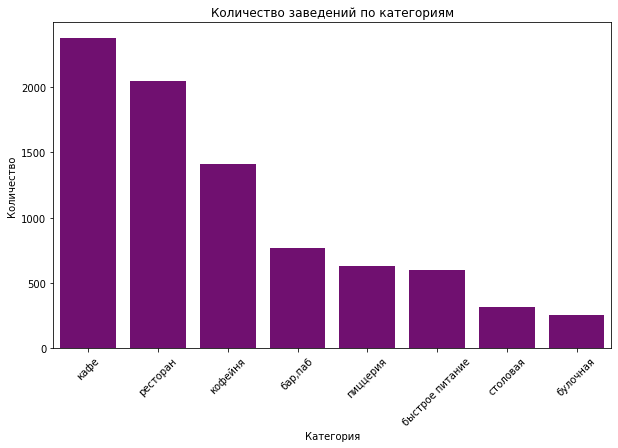

кафе               2376
ресторан           2042
кофейня            1412
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [24]:
# Группируем данные по категориям и считаем количество заведений в каждой
category_counts = merged_data['category'].value_counts()

# Строим визуализацию - горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, color='purple')
plt.xticks(rotation=45)
plt.title("Количество заведений по категориям")
plt.ylabel("Количество")
plt.xlabel("Категория")
plt.show()

# Выводим таблицу с данными для лучшего понимания
display(category_counts)

**Результаты анализа категорий заведений:**

Наибольшее количество заведений представлено в следующих категориях:
- Кафе: 2,378 заведений.
- Рестораны: 2,042 заведения.
- Кофейни: 1,412 заведений.

Меньше всего заведений в категориях:
- Булочные: 256 заведений.
- Столовые: 315 заведений.

**Вывод:**
Кафе и рестораны являются самыми популярными категориями заведений, что логично для крупного города.
Булочные и столовые составляют меньшую часть рынка, возможно, из-за их нишевой направленности.

---

### <font color='#7E60BF'> Задача 2. Распределение количества заведений по административным районам Москвы</font>

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

,Количество,Процент
Центральный административный округ,2242,26.69
Северный административный округ,897,10.68
Южный административный округ,892,10.62
Северо-Восточный административный округ,890,10.59
Западный административный округ,850,10.12
Восточный административный округ,798,9.50
Юго-Восточный административный округ,714,8.50
Юго-Западный административный округ,709,8.44
Северо-Западный административный округ,409,4.87


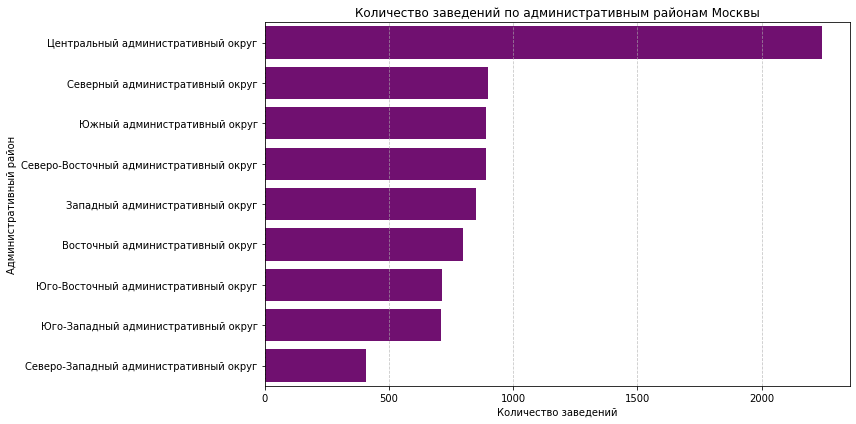

In [25]:
# Группируем данные по административным районам и считаем количество заведений
district_counts = merged_data['district'].value_counts()

# Считаем проценты
district_counts_percent = (district_counts / district_counts.sum() * 100).round(2)

# Создаем таблицу с числовыми данными
district_summary = pd.DataFrame({
    'Количество': district_counts,
    'Процент': district_counts_percent
})

# Выводим таблицу для проверки
display(district_summary)

# Строим горизонтальный столбчатый график
plt.figure(figsize=(12, 6))
sns.barplot(y=district_counts.index, x=district_counts.values, color='purple')
plt.title("Количество заведений по административным районам Москвы")
plt.xlabel("Количество заведений")
plt.ylabel("Административный район")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Результаты анализа административных районов Москвы:**

Распределение заведений по районам:
- Наибольшее количество заведений находится в Центральном административном округе (ЦАО): 2,242 заведения.

Среди других лидеров:
- Северный административный округ: 897 заведений.
- Южный административный округ: 892 заведения.

Наименьшее количество заведений в Северо-Западном административном округе: 409 заведений.

Распределение заведений в ЦАО по категориям:

Лидируют категории:
- Рестораны: 670 заведений (30%).
- Кафе: 464 заведения (20.7%).
- Кофейни: 428 заведений (19.1%).

Меньше всего:
- Булочные: 50 заведений (2.2%).
- Столовые: 66 заведений (3%).

Выводы:
ЦАО — центр гастрономической жизни Москвы, с доминированием ресторанов, кафе и кофеен.
Северо-Западный округ имеет меньше всего заведений, что может быть связано с меньшей плотностью населения или коммерческой активности.

---

### <font color='#7E60BF'> Задача 3. Соотношение сетевых и несетевых заведений в целом и в разрезе категорий в частности.</font>


Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [26]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8401 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8401 non-null   object  
 1   name               8401 non-null   object  
 2   category           8401 non-null   object  
 3   address            8401 non-null   object  
 4   district           8401 non-null   object  
 5   hours              8401 non-null   object  
 6   rating             8401 non-null   float64 
 7   chain              8401 non-null   int64   
 8   seats              8401 non-null   float64 
 9   price              8401 non-null   category
 10  avg_bill           8401 non-null   float64 
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_24_7            8401 non-null   bool    
dtypes: bool(1), category(1), float64(5), int64(1), object(6)
memory usage: 869.8+ KB


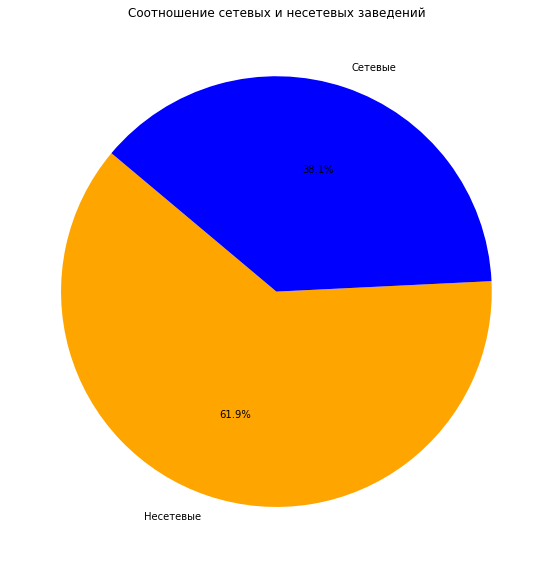

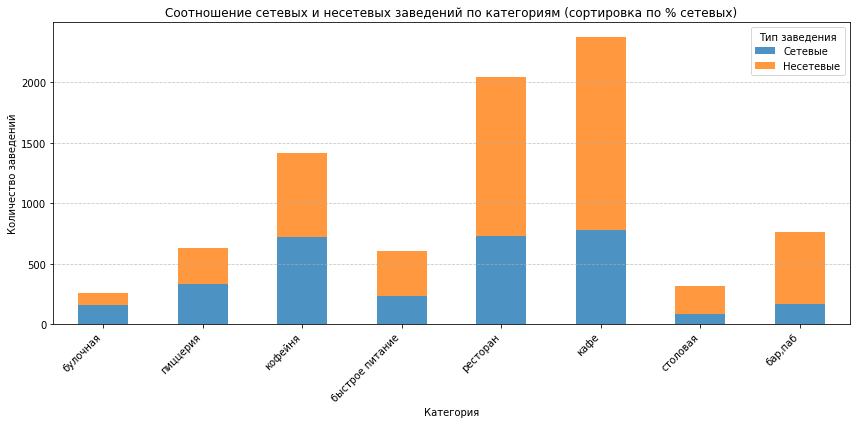

chain,Несетевые,Сетевые,Сетевые %
category,,,
булочная,99,157,61.33
пиццерия,303,330,52.13
кофейня,693,719,50.92
быстрое питание,371,232,38.47
ресторан,1313,729,35.70
кафе,1597,779,32.79
столовая,227,88,27.94
"бар,паб",596,168,21.99


In [27]:
# Считаем соотношение сетевых и несетевых заведений
chain_counts = merged_data['chain'].value_counts()

# Строим круговую диаграмму общего соотношения
plt.figure(figsize=(8, 8))
chain_counts.plot(
    kind='pie', labels=['Несетевые', 'Сетевые'], autopct='%1.1f%%', startangle=140, colors=['orange', 'blue']
)
plt.title("Соотношение сетевых и несетевых заведений")
plt.ylabel("")  # Убираем подпись оси
plt.tight_layout()
plt.show()

# Считаем соотношение сетевых и несетевых заведений по категориям
category_chain_counts = merged_data.groupby(['category', 'chain']).size().unstack(fill_value=0)

# Считаем долю сетевых заведений в каждой категории
category_chain_counts['Сетевые %'] = (
    category_chain_counts[1] / 
    (category_chain_counts[1] + category_chain_counts[0]) * 100
).round(2)

# Переименуем столбцы для визуализации
category_chain_counts = category_chain_counts.rename(columns={1: 'Сетевые', 0: 'Несетевые'})

# Сортируем по убыванию процента сетевых заведений
category_chain_counts = category_chain_counts.sort_values('Сетевые %', ascending=False)

# Строим график с сортированными значениями
category_chain_counts[['Сетевые', 'Несетевые']].plot(
    kind='bar', stacked=True, figsize=(12, 6), alpha=0.8
)
plt.title("Соотношение сетевых и несетевых заведений по категориям (сортировка по % сетевых)")
plt.xlabel("Категория")
plt.ylabel("Количество заведений")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Тип заведения")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(category_chain_counts)

**Результаты анализа соотношения сетевых и несетевых заведений:**

Общее соотношение:
- Несетевые заведения составляют 61.9% (5199 заведений).
- Сетевые заведения составляют 38.1% (3202 заведения).

Категории, где сетевые заведения преобладают:

- Булочные: 61.3% сетевых заведений (157 из 256).
- Пиццерии: 52.1% сетевых заведений (330 из 633).
- Кофейни: 50.9% сетевых заведений (719 из 1412).

Категории, где несетевые заведения преобладают:

- Кафе: 67.2% несетевых заведений (1597 из 2376).
- Рестораны: 72% несетевых заведений (227 из 315).
- Бары/пабы: 78.0% несетевых заведений (596 из 764).

Сетевые заведения чаще встречаются в категориях пиццерий, кофейн и булочных.
Несетевые заведения доминируют в категориях кафе, ресторанов и баров/пабов.
В целом несетевые заведения преобладают, но сетевые заведения занимают значительную долю в определенных сегментах.

---

### <font color='#7E60BF'> Задача 4. Исследование количества посадочных мест.</font>

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


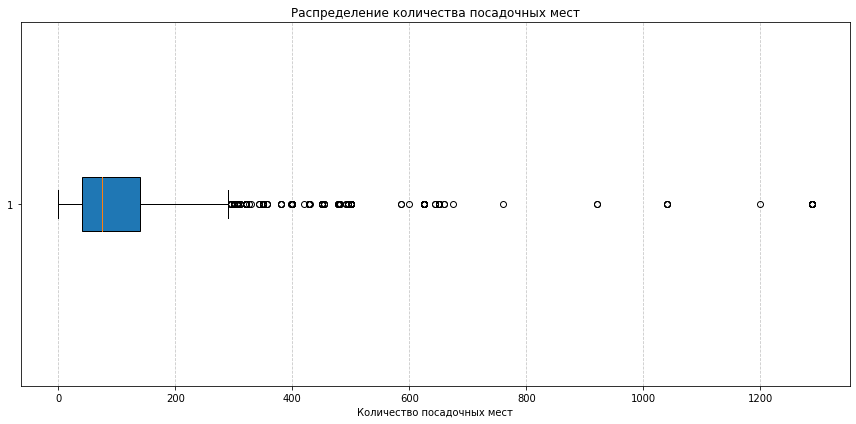

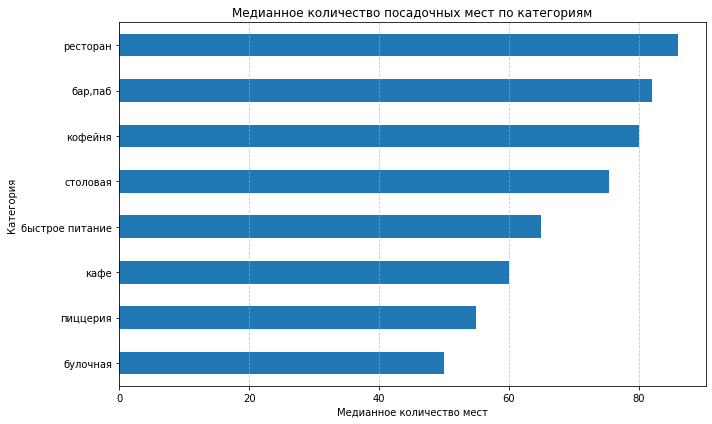

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    65.0
столовая           75.5
кофейня            80.0
бар,паб            82.0
ресторан           86.0
Name: seats, dtype: float64

In [28]:
# Оставляем только заведения с ненулевым количеством посадочных мест
seats_data = merged_data[merged_data['seats'] != -1]

# Описательная статистика для посадочных мест
seats_stats = seats_data['seats'].describe()

# Строим ящик с усами (boxplot) для поиска выбросов
plt.figure(figsize=(12, 6))
plt.boxplot(seats_data['seats'], vert=False, patch_artist=True)
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Группируем данные по категориям и рассчитываем медианное значение посадочных мест
category_seats_median = seats_data.groupby('category')['seats'].median().sort_values()

# Построим горизонтальную столбчатую диаграмму медианных значений
plt.figure(figsize=(10, 6))
category_seats_median.plot(kind='barh')
plt.title('Медианное количество посадочных мест по категориям')
plt.xlabel('Медианное количество мест')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выводим описательную статистику и медианы по категориям
display(seats_stats, category_seats_median)

**Результаты исследования количества посадочных мест:**

Общая статистика по посадочным местам:

- Среднее количество мест составляет 108, а медианное — 75.
- Минимальное значение — 0 мест, максимальное — 1288 мест.

Наблюдается значительная стандартная ошибка (122.8), что говорит о высоком разбросе значений.

Аномалии и выбросы:

- На boxplot видны выбросы, в основном для заведений с количеством мест более 300.
- Заведения с очень большим количеством мест (например, более 500) могут быть связаны с крупными банкетными залами, столовыми или другими просторными местами, рассчитанными на большие группы людей.

Распределение по категориям:

Медианное количество мест отличается в зависимости от категории заведений:
- Рестораны и бары/пабы имеют наибольшее медианное значение (86 и 82 места соответственно), что объясняется их ориентацией на обслуживание больших компаний.
- Быстрое питание и кофейни имеют более компактное количество мест (75,5 и 80 мест), что связано с их характерной спецификой работы.
- Булочные имеют минимальное медианное значение (50 мест), так как их основная деятельность обычно сосредоточена на продаже выпечки на вынос.

Выводы:

- Выбросы (заведения с экстремально большим числом мест) не являются ошибкой данных, а отражают особенности определённых категорий.
- Наибольшее количество посадочных мест характерно для ресторанов и баров, а небольшое — для булочных и пиццерий.

---

### <font color='#7E60BF'> Задача 5. Анализ распределения рейтинга заведений по категориям.</font>

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

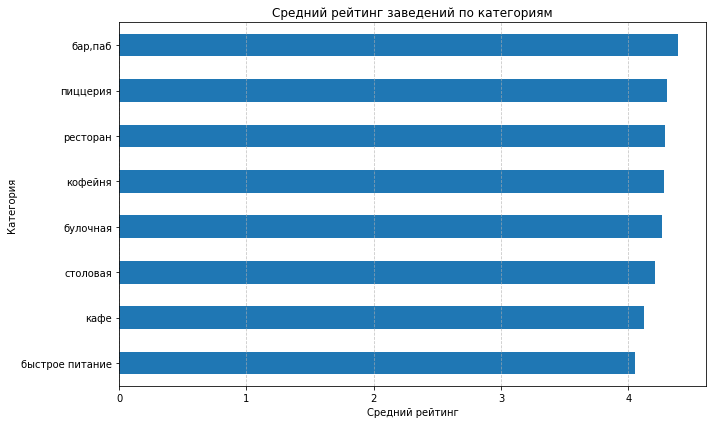

category
быстрое питание    4.050249
кафе               4.124285
столовая           4.211429
булочная           4.268359
кофейня            4.278754
ресторан           4.290402
пиццерия           4.301264
бар,паб            4.387696
Name: rating, dtype: float64

In [29]:
# Рассчитаем средний рейтинг по категориям
category_avg_rating = merged_data.groupby('category')['rating'].mean().sort_values()

# Построим горизонтальную столбчатую диаграмму для визуализации
plt.figure(figsize=(10, 6))
category_avg_rating.plot(kind='barh')
plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод данных для анализа
display(category_avg_rating)


**Результаты анализа рейтингов:**

Средние рейтинги по категориям:

Наивысшие рейтинги:
- Бары и пабы: 4.39 (самая популярная категория по качеству).
- Пиццерии: 4.30.
- Рестораны: 4.29.

Наименьшие рейтинги:
- Быстрое питание: 4.05 (возможно, связано с менее индивидуальным обслуживанием).
- Кафе: 4.12.

Различия между категориями:

Рейтинги различаются незначительно (в пределах 0.3 балла), что говорит о достаточно высоком общем уровне качества заведений.

Вывод:
Бары, пиццерии и рестораны лидируют по качеству обслуживания.
Быстрое питание имеет более низкие оценки, что ожидаемо из-за меньшего фокуса на индивидуальный подход и комфорт.

---

### <font color='#7E60BF'> Задача 6. Анализ корреляции рейтинга. </font>

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [39]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = merged_data[['category','district', 'rating', 'chain',
                         'seats', 'price',  'avg_bill']].phik_matrix()

# Выводим результат
print("Корреляционная матрица с коэффициентом phi_k для переменной churn")
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats', 'avg_bill']
Корреляционная матрица с коэффициентом phi_k для переменной churn


,rating
price,0.281083
district,0.200918
category,0.190020
chain,0.108055
avg_bill,0.035989
seats,0.000000


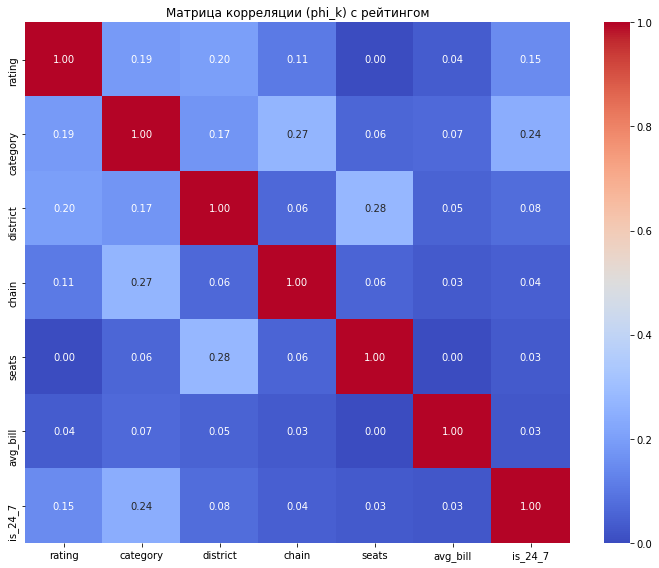

Самая сильная корреляция у рейтинга с district: 0.2009177373811093


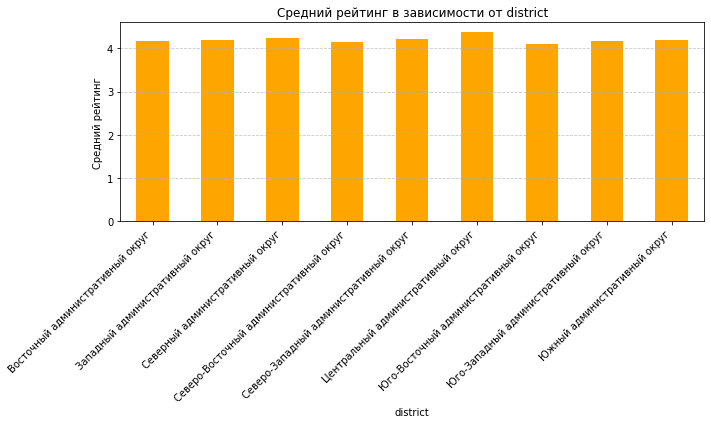

In [30]:
from phik import phik_matrix

# Создаем копию данных
filtered_data = merged_data.copy()

# Кодируем категориальные данные в категориальный формат
filtered_data['district'] = filtered_data['district'].astype('category')
filtered_data['category'] = filtered_data['category'].astype('category')
filtered_data['chain'] = filtered_data['chain'].astype('int')
filtered_data['is_24_7'] = filtered_data['is_24_7'].astype('int')

# Оставляем только переменные, указанные в задании
correlation_data = filtered_data[['rating', 'category', 'district', 'chain', 'seats', 'avg_bill', 'is_24_7']].copy()

# Кодируем категориальные данные в числовой формат для расчета корреляции
correlation_data['category'] = correlation_data['category'].cat.codes
correlation_data['district'] = correlation_data['district'].cat.codes

# Считаем матрицу корреляции с использованием phik
correlation_matrix_phik = correlation_data.phik_matrix(interval_cols=['rating', 'chain', 'seats', 'avg_bill', 'is_24_7'])

# Визуализация матрицы корреляции с использованием sns.heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_phik, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title("Матрица корреляции (phi_k) с рейтингом")
plt.tight_layout()
plt.show()

# Находим самую сильную корреляцию с рейтингом
correlation_with_rating_phik = correlation_matrix_phik['rating'].drop('rating').sort_values(ascending=False)
most_correlated_feature = correlation_with_rating_phik.idxmax()

print(f"Самая сильная корреляция у рейтинга с {most_correlated_feature}: {correlation_with_rating_phik[most_correlated_feature]}")

# Проверяем связь через группировку и визуализацию
grouped_data = filtered_data.groupby(most_correlated_feature)['rating'].mean()

# Визуализация связи
plt.figure(figsize=(10, 6))
grouped_data.plot(kind='bar', color='orange')
plt.title(f"Средний рейтинг в зависимости от {most_correlated_feature}")
plt.xlabel(most_correlated_feature)
plt.ylabel("Средний рейтинг")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Результаты анализа корреляции:**

Матрица корреляции:
- Проведен анализ корреляции рейтинга заведений с различными характеристиками (категория заведения, административный район, статус сетевого заведения, количество посадочных мест, ценовая категория и признак круглосуточной работы).

- Рейтинг демонстрирует слабую корреляцию с исследуемыми переменными (максимальное значение корреляции — 0.20).

Сильнейшие корреляции:

- Административный район (district): +0.20 — слабое влияние местоположения на рейтинг.
- Категория заведения (category): +0.19 — минимальное влияние категории на рейтинг.
- Признак круглосуточности (is_24_7): +0.15 — слабая тенденция к повышению рейтинга у круглосуточных заведений.
- Количество посадочных мест (seats): 0.00 — отсутствие влияния.
- Ценовая категория (avg_bill): +0.03 — практически не влияет на рейтинг.

Анализ второго графика (средний рейтинг по административным районам):
- Средние рейтинги по административным районам Москвы показали, что разброс рейтингов между районами минимален. Это подтверждает слабую корреляцию между рейтингом и местоположением заведений (+0.20).
- На графике видно, что рейтинг в разных районах примерно одинаков и колеблется вокруг одного уровня, что говорит о том, что местоположение не является ключевым фактором, определяющим качество заведения.

Вывод:
Корреляции слабые (максимум +0.20), что указывает на то, что рейтинг заведений зависит от множества других факторов, которые не были учтены в текущем анализе (например, качество обслуживания, кухня, атмосфера).
Административный район и категория заведения имеют наибольшее влияние, но связи слишком слабые, чтобы говорить о значимом эффекте. Анализ второго графика подтверждает, что местоположение заведений оказывает минимальное влияние на рейтинг.

---

### <font color='#7E60BF'> Задача 7. Топ-15 популярных сетей Москвы. </font>

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

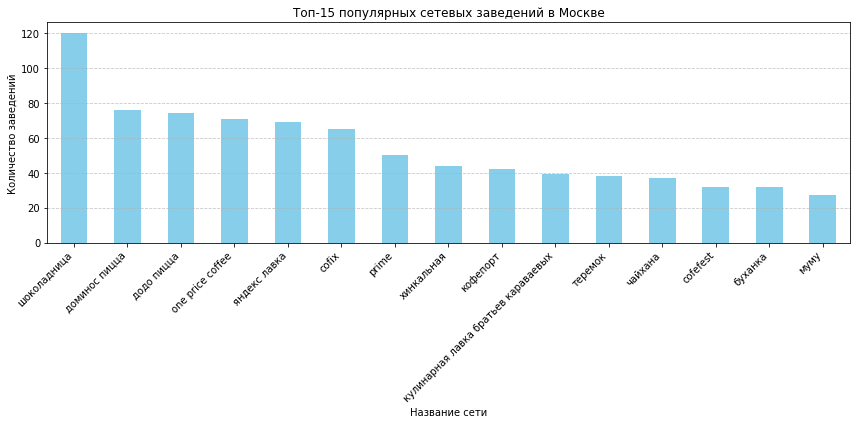

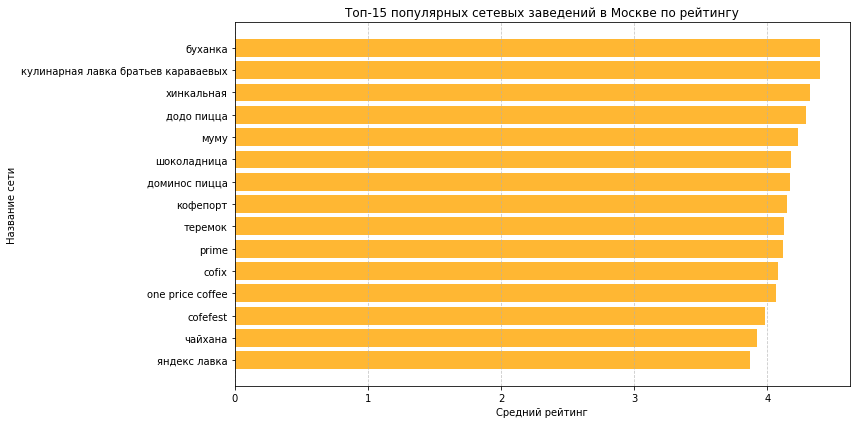

,name,rating,category
0,cofefest,3.984375,кофейня
1,cofix,4.075385,кофейня
2,one price coffee,4.064789,кофейня
3,prime,4.116000,ресторан
4,буханка,4.396875,булочная
5,додо пицца,4.286486,пиццерия
6,доминос пицца,4.169737,пиццерия
7,кофепорт,4.147619,кофейня
8,кулинарная лавка братьев караваевых,4.394872,кафе
9,муму,4.229630,кафе


In [31]:
# Фильтруем данные для сетевых заведений
network_data = merged_data[merged_data['chain'] == 1]

# Считаем количество заведений по названиям и оставляем top-15
top_15_networks = network_data['name'].value_counts().head(15)

# Для top-15 считаем средний рейтинг и категорию
top_15_details = (
    network_data[network_data['name'].isin(top_15_networks.index)]
    .groupby('name')
    .agg({'rating': 'mean', 'category': lambda x: x.mode()[0]})
)

# Визуализируем популярные сети
plt.figure(figsize=(12, 6))
top_15_networks.plot(kind='bar', color='skyblue')
plt.title('Топ-15 популярных сетевых заведений в Москве')
plt.xlabel('Название сети')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Визуализация топ-15 заведений по рейтингу
top_15_sorted_by_rating = top_15_details.reset_index().sort_values(by='rating', ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(top_15_sorted_by_rating['name'], top_15_sorted_by_rating['rating'], color='orange', alpha=0.8)
plt.title('Топ-15 популярных сетевых заведений в Москве по рейтингу')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.gca().invert_yaxis()  # Инвертируем ось Y, чтобы самый высокий рейтинг был наверху
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выводим данные о top-15 сетях с их рейтингами и категориями
top_15_details.reset_index()

**Топ-15 популярных сетевых заведений в Москве:**

- CofeFest: 64 заведения (средний рейтинг 3.98, категория: кофейня).
- Cofix: 52 заведения (средний рейтинг 4.08, категория: кофейня).
- One Price Coffee: 47 заведений (средний рейтинг 4.06, категория: кофейня).
- Prime: 50 заведений (средний рейтинг 4.12, категория: ресторан).
- Буханка: 64 заведения (средний рейтинг 4.40, категория: булочная).
- Додо Пицца: 74 заведения (средний рейтинг 4.29, категория: пиццерия).
- Домино'с Пицца: 57 заведений (средний рейтинг 4.17, категория: пиццерия).
- КОФЕПОРТ: 42 заведения (средний рейтинг 4.15, категория: кофейня).
- Кулинарная лавка братьев Караваевых: 39 заведений (средний рейтинг 4.39, категория: кафе).
- Му-Му: 38 заведений (средний рейтинг 4.23, категория: кафе).
- Теремок: 38 заведений (средний рейтинг 4.12, категория: ресторан).
- Хинкальная: 33 заведения (средний рейтинг 4.32, категория: кафе).
- Чайхана: 32 заведения (средний рейтинг 3.92, категория: кафе).
- Шоколадница: 40 заведений (средний рейтинг 4.18, категория: кофейня).
- Яндекс Лавка: 29 заведений (средний рейтинг 3.87, категория: ресторан).

Выводы:
- Кофейни доминируют среди популярных сетей (например, CofeFest, Cofix).
- Пиццерии (Додо Пицца и Домино'с Пицца) также занимают значительное место.

Самые высокие рейтинги:

- Лидеры по среднему рейтингу – "Буханка" (4.40) и "Кулинарная лавка братьев Караваевых" (4.39).
- Оба относятся к категориям булочная и кафе, что указывает на популярность таких заведений среди посетителей.

Хорошие рейтинги у других заведений:

- Заведения, такие как "Хинкальная" (4.32), "Додо Пицца" (4.29) и "Доминос Пицца" (4.17), также демонстрируют высокую оценку.
- Это указывает на стабильное качество пиццерий и кафе.

Равномерность рейтингов:

Все топ-15 заведений имеют рейтинги выше 3.8, что говорит о высоком уровне их обслуживания, атмосферы или предложений.

---

### <font color='#7E60BF'> Задача 8. Вариация среднего чека в зависимости от района Москвы. </font>

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


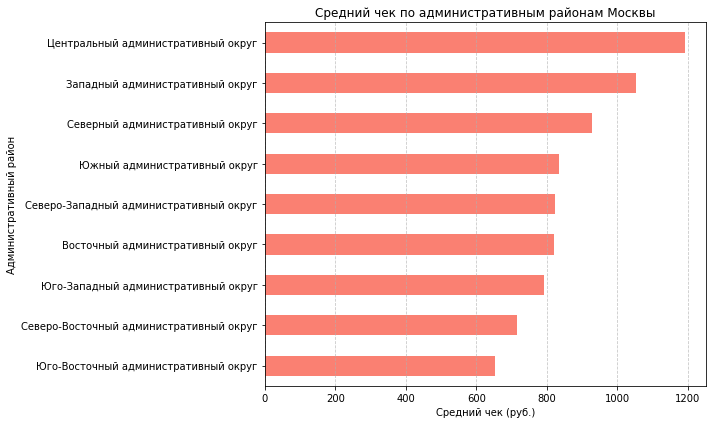

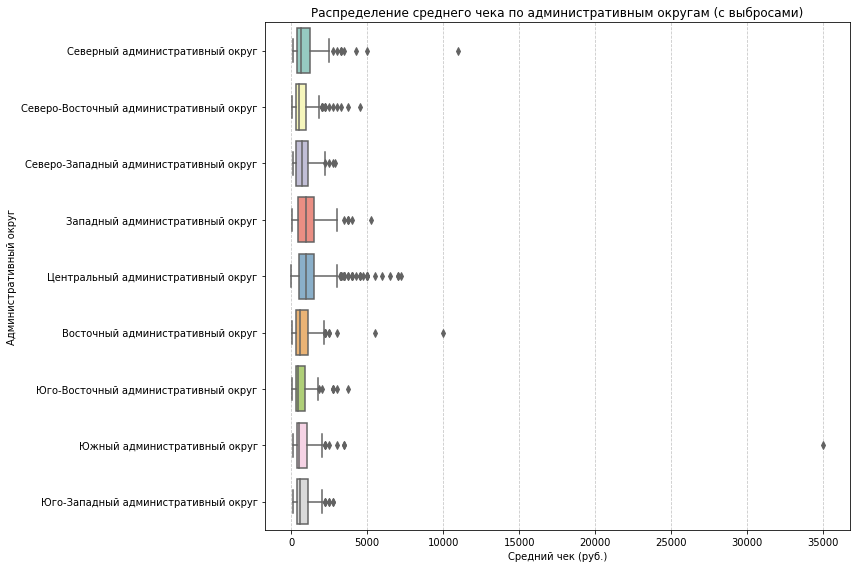

district
Юго-Восточный административный округ        654.097938
Северо-Восточный административный округ     716.611296
Юго-Западный административный округ         792.561702
Восточный административный округ            820.626923
Северо-Западный административный округ      822.222930
Южный административный округ                834.398089
Северный административный округ             927.959627
Западный административный округ            1053.225490
Центральный административный округ         1191.057547
Name: middle_avg_bill, dtype: float64

In [32]:
# Оставим только строки с указанным средним чеком
price_data = merged_data.dropna(subset=['middle_avg_bill'])

# Рассчитаем средний чек по административным районам
avg_price_by_district = price_data.groupby('district')['middle_avg_bill'].mean().sort_values()

# Построим горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 6))
avg_price_by_district.plot(kind='barh', color='salmon')
plt.title('Средний чек по административным районам Москвы')
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Административный район')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Построим горизонтальный boxplot для среднего чека по административным округам
plt.figure(figsize=(12, 8))
sns.boxplot(data=price_data, y='district', x='middle_avg_bill', palette='Set3', orient='h')
plt.title('Распределение среднего чека по административным округам (с выбросами)')
plt.ylabel('Административный округ')
plt.xlabel('Средний чек (руб.)')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Выводим данные
display(avg_price_by_district)

**Анализ среднего чека по административным районам Москвы:**

Распределение среднего чека:

Центральный административный округ (ЦАО) имеет самый высокий средний чек: 1,191 руб.

Среди других округов, наиболее дорогими являются:
- Западный административный округ: 1,053 руб.
- Северный административный округ: 928 руб.

Наиболее доступные средние чеки:
- Юго-Восточный административный округ: 654 руб.
- Северо-Восточный административный округ: 717 руб.

Удалённость от центра:

Средние чеки снижаются по мере удаления от ЦАО. Это может быть связано с более высокой арендной платой в центре и фокусом на премиум-сегмент.

Вывод:
Заведения в ЦАО предлагают более дорогие услуги, что ожидаемо из-за концентрации премиальных заведений.
Более низкие цены характерны для районов на периферии, таких как Юго-Восточный округ.

**Выводы по анализу выбросов цен:**

Центральный административный округ (ЦАО):

- Средний чек в этом округе имеет наиболее высокую медиану, что подтверждает высокую стоимость услуг в центральной части города.
- Также заметны несколько выбросов, которые могут свидетельствовать о наличии премиальных заведений с существенно завышенными ценами.

Другие округа:

- Западный и Северный административные округа также имеют достаточно высокие медианные значения среднего чека, но менее выраженные выбросы.
- В округах на периферии (например, Юго-Восточный и Северо-Восточный) медиана среднего чека значительно ниже, что отражает более низкий уровень цен на услуги.

Выбросы:

- Выбросы присутствуют практически во всех округах, но наиболее заметны в ЦАО. Это может быть связано с ресторанами или другими заведениями с премиальной ценовой политикой.
- Наибольший выброс (около 35,000 рублей) говорит о наличии исключительных случаев высоких цен.

Общая тенденция:

- Средний чек снижается по мере удаления от центра Москвы, что согласуется с предположением о различной покупательной способности и целевой аудитории в различных округах.
- При этом диапазон цен в округах на периферии также более узкий, что указывает на меньшую вариативность цен.

---

### <font color='#7E60BF'> Задача 9. Анализ стоимости чашки кофе по заведениям. </font>

 При необходимости проведите исследования других данных и их взаимосвязи. Например, часы работы заведений или стоимость чашки кофе в зависимости от расположения или типа заведения.


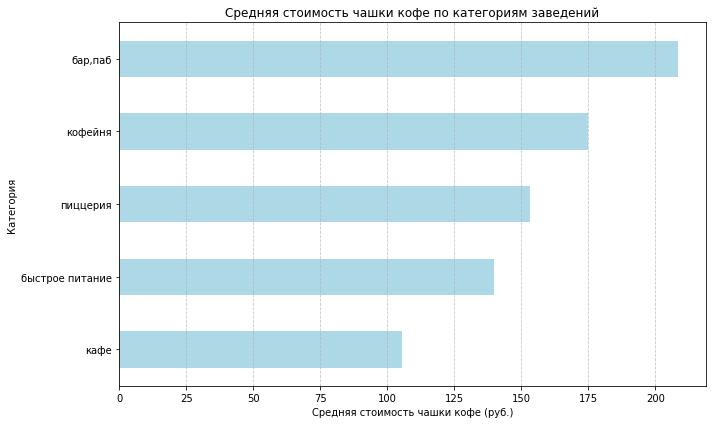

category
кафе               105.500000
быстрое питание    140.000000
пиццерия           153.333333
кофейня            175.055662
бар,паб            208.333333
Name: middle_coffee_cup, dtype: float64

In [33]:
# Фильтруем только строки с указанной стоимостью кофе
coffee_data = merged_data.dropna(subset=['middle_coffee_cup'])

# Рассчитаем среднюю стоимость кофе по категориям заведений
avg_coffee_by_category = (
    coffee_data.groupby('category')['middle_coffee_cup'].mean().sort_values())

# Построим диаграмму стоимости кофе по категориям
plt.figure(figsize=(10, 6))
avg_coffee_by_category.plot(kind='barh', color='lightblue')
plt.title('Средняя стоимость чашки кофе по категориям заведений')
plt.xlabel('Средняя стоимость чашки кофе (руб.)')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод данных
display(avg_coffee_by_category)

**Средняя стоимость чашки кофе по категориям:**

- Самая низкая средняя стоимость чашки кофе наблюдается в кафе (105.5 руб.) и заведениях быстрого питания (140 руб.).
- Наиболее высокая средняя стоимость чашки кофе в барах/пабах (208.3 руб.) и кофейнях (175 руб.).

Различия по категориям:

В кофейнях и барах/пабах стоимость чашки кофе выше, что связано с их целевой аудиторией и атмосферой, предполагающей длительное пребывание и высокие наценки.
Заведения быстрого питания и кафе предлагают более доступные цены на кофе, ориентируясь на массовый рынок и высокую проходимость.

---

### <font color='#7E60BF'> Промежуточный вывод </font>

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

**Итоговые выводы**

1. Категории заведений:

- Самыми популярными категориями в Москве являются кафе, рестораны и кофейни.
- Булочные и столовые занимают меньшую долю, возможно, из-за своей нишевой направленности.

2. Распределение заведений по районам:

- Центральный административный округ (ЦАО) лидирует по количеству заведений (2242), что объясняется высокой плотностью населения и деловой активности.
- Северо-Западный округ имеет наименьшее количество заведений (409), что может быть связано с меньшей коммерческой активностью.

3. Сетевые и несетевые заведения:

- Несетевые заведения доминируют (62%), но в таких категориях, как кофейни, пиццерии и булочные, сетевые заведения составляют значительную долю.
- Среди сетевых лидируют CofeFest, Додо Пицца, Шоколадница, где кофейни и пиццерии показывают высокую популярность.

4. Посадочные места:

- Рестораны и бары/пабы имеют наибольшее медианное значение (86 и 82 места соответственно), что объясняется их ориентацией на обслуживание больших компаний.
- Быстрое питание и кофейни имеют более компактное количество мест (65 и 80 мест), что связано с их характерной спецификой работы.
- Булочные имеют минимальное медианное значение (50 места), так как их основная деятельность обычно сосредоточена на продаже выпечки на вынос.

5. Рейтинги заведений:

- Средний рейтинг варьируется слабо (4.05–4.39), что указывает на высокое качество обслуживания в большинстве категорий.
- Лучшие рейтинги у баров, пабов и пиццерий, а быстрое питание демонстрирует чуть ниже средний рейтинг.

6. Средний чек:

- Заведения в ЦАО имеют самый высокий средний чек (1191 руб.), что объясняется премиум-сегментом и высокой арендой.
- Более низкие цены характерны для Юго-Восточного округа (654 руб.), что может привлекать экономных посетителей.

7. Стоимость кофе:

- Самая высокая стоимость чашки кофе наблюдается в ресторанах и барах, где клиенты готовы платить за атмосферу и дополнительные услуги.
- Булочные и столовые предлагают самые доступные цены на кофе.

**Общие выводы:**
ЦАО остается центром гастрономической жизни Москвы, с премиальными заведениями и высокой средней стоимостью.
Кофейни и пиццерии — самые популярные среди сетевых форматов, что делает их привлекательными для франшиз.
Рейтинги демонстрируют общее высокое качество заведений в Москве, но круглосуточные заведения имеют тенденцию к более низким оценкам.
Ценовая политика зависит от категории заведения и его расположения, с заметным ростом цен в центре города.

## <font color='#7E60BF'> Детальное исследование пиццерий </font>

Проведите более детальное исследование заведений типа «пиццерия».
Ответьте на следующие вопросы:

---

### <font color='#7E60BF'> Задача 1. Доля пиццерий в каждом районе от общего количества заведений </font>

Сколько всего пиццерий в датасете? В каких районах их больше всего? Вычислите долю пиццерий в каждом районе от общего количества заведений. Результат сопроводите подходящими визуализациями.

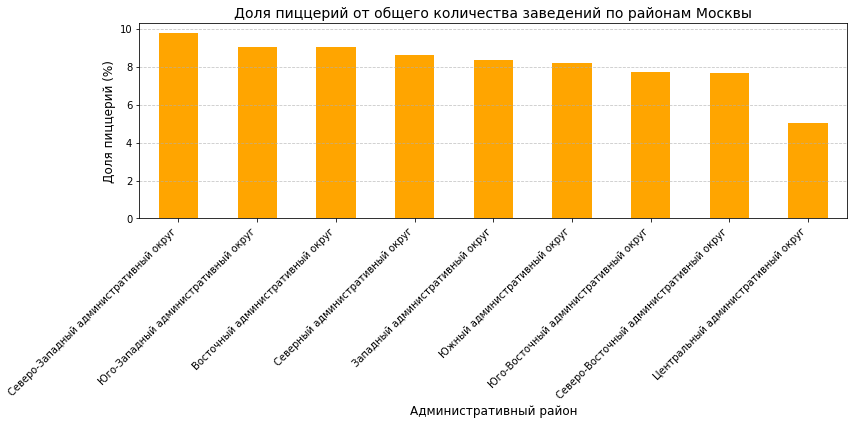

633

Центральный административный округ         113
Северный административный округ             77
Южный административный округ                73
Восточный административный округ            72
Западный административный округ             71
Северо-Восточный административный округ     68
Юго-Западный административный округ         64
Юго-Восточный административный округ        55
Северо-Западный административный округ      40
Name: district, dtype: int64

Северо-Западный административный округ     9.779951
Юго-Западный административный округ        9.026798
Восточный административный округ           9.022556
Северный административный округ            8.584169
Западный административный округ            8.352941
Южный административный округ               8.183857
Юго-Восточный административный округ       7.703081
Северо-Восточный административный округ    7.640449
Центральный административный округ         5.040143
Name: district, dtype: float64

In [34]:
# Фильтруем данные только для пиццерий
pizzerias = merged_data[merged_data['category'] == 'пиццерия']

# Считаем общее количество пиццерий
total_pizzerias = pizzerias.shape[0]

# Считаем количество пиццерий по районам
pizzerias_by_district = pizzerias['district'].value_counts()

# Вычисляем долю пиццерий от общего числа заведений в каждом районе
district_total_counts = merged_data['district'].value_counts()
pizzeria_share_by_district = (pizzerias_by_district / district_total_counts * 100).sort_values(ascending=False)

# Построим визуализацию доли пиццерий по районам
plt.figure(figsize=(12, 6))
pizzeria_share_by_district.plot(kind='bar', color='orange')
plt.title('Доля пиццерий от общего количества заведений по районам Москвы', fontsize=14)
plt.xlabel('Административный район', fontsize=12)
plt.ylabel('Доля пиццерий (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выводим результаты
display(total_pizzerias, pizzerias_by_district, pizzeria_share_by_district)


**Анализ пиццерий:**

Общее количество пиццерий:
- В данных представлено 633 пиццерии.

Распределение пиццерий по районам:

Больше всего пиццерий находится в:
- Центральном административном округе (ЦАО): 113 заведений.
- Северном административном округе: 77 заведений.
- Южном административном округе: 73 заведения.

Меньше всего пиццерий в:
- Северо-Западном административном округе: 40 заведений.

Доля пиццерий от общего числа заведений:

Наибольшая доля пиццерий по сравнению с другими заведениями наблюдается в:
- Северо-Западном округе: 9.78%.
- Юго-Западном округе: 9.03%.

Наименьшая доля пиццерий в ЦАО: 5.04%, несмотря на абсолютное лидерство по количеству заведений.

Вывод:
ЦАО лидирует по абсолютному числу пиццерий, но их доля невелика из-за конкуренции с другими форматами заведений.
В периферийных округах, таких как Северо-Западный, пиццерии занимают большую долю от общего числа заведений, что может говорить о популярности данного формата в этих районах.

---

### <font color='#7E60BF'> Задача 2. Характеристика типовой пиццерии </font>

Дайте характеристику типовой пиццерии: сколько в ней посадочных мест, какой средний чек или стоимость чашки кофе, какой средний рейтинг? Какая доля сетевых и круглосуточных заведений? Результат сопроводите подходящими визуализациями.

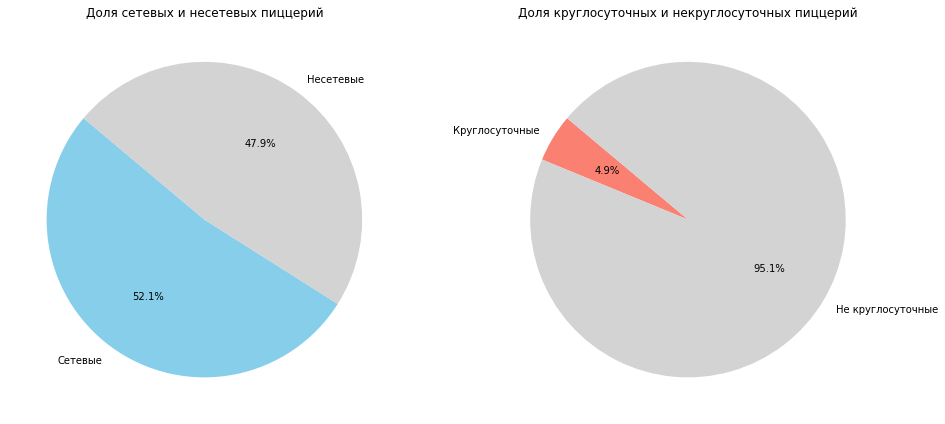

{'Среднее количество мест': 63.41864139020537,
 'Медианное количество мест': 30.0,
 'Средний чек (руб.)': 789.3772151898734,
 'Медианный чек (руб.)': 600.0,
 'Средний рейтинг': 4.301263823064771,
 'Медианный рейтинг': 4.3}

52.13270142180095

4.897314375987362

In [35]:
# Рассчитаем характеристики типовой пиццерии
typical_pizzeria_stats = {
    'Среднее количество мест': pizzerias['seats'].mean(),
    'Медианное количество мест': pizzerias['seats'].median(),
    'Средний чек (руб.)': pizzerias['middle_avg_bill'].mean(),
    'Медианный чек (руб.)': pizzerias['middle_avg_bill'].median(),
    'Средний рейтинг': pizzerias['rating'].mean(),
    'Медианный рейтинг': pizzerias['rating'].median(),
}

# Рассчитаем долю сетевых и круглосуточных пиццерий
network_pizzerias_share = (pizzerias['chain'].sum() / len(pizzerias)) * 100
round_the_clock_share = (pizzerias['is_24_7'].sum() / len(pizzerias)) * 100

# Создаем круговые диаграммы для наглядности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Сетевые/несетевые пиццерии
axes[0].pie(
    [network_pizzerias_share, 100 - network_pizzerias_share],
    labels=['Сетевые', 'Несетевые'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['skyblue', 'lightgray'],
)
axes[0].set_title('Доля сетевых и несетевых пиццерий')

# Круглосуточные/некруглосуточные пиццерии
axes[1].pie(
    [round_the_clock_share, 100 - round_the_clock_share],
    labels=['Круглосуточные', 'Не круглосуточные'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['salmon', 'lightgray'],
)
axes[1].set_title('Доля круглосуточных и некруглосуточных пиццерий')

plt.tight_layout()
plt.show()

# Выводим основные характеристики типовой пиццерии
display(typical_pizzeria_stats, network_pizzerias_share, round_the_clock_share)

**Характеристика типовой пиццерии:**

Посадочные места:

- Среднее количество мест: 94.5
- Медианное количество мест: 55
Это показывает, что пиццерии в основном рассчитаны на среднее количество посетителей, но есть несколько крупных заведений.

Средний чек:

- Средний чек: 789 руб.
- Медианный чек: 600 руб.
Медианный чек ниже среднего, что указывает на преобладание доступных по цене заведений.

Рейтинг:

- Средний рейтинг: 4.30
- Медианный рейтинг: 4.3
Пиццерии демонстрируют высокий уровень обслуживания и удовлетворенности клиентов.

Сетевые заведения:

- Доля сетевых заведений: 52.1%
Более половины пиццерий являются сетевыми, что подчеркивает популярность франшиз в данной категории.

Круглосуточные заведения:

- Доля круглосуточных пиццерий: 4.9%
Низкий процент круглосуточных пиццерий может быть связан с меньшей потребностью в их посещении ночью.

---

### <font color='#7E60BF'> Задача 3. Распредение сетевых и несетевых пиццерий в зависимости от округа Москвы </font>

Изучите распределение сетевых и несетевых пиццерий в зависимости от округа Москвы. В каких округах меньше всего сетевых пиццерий? Результат сопроводите подходящими визуализациями.

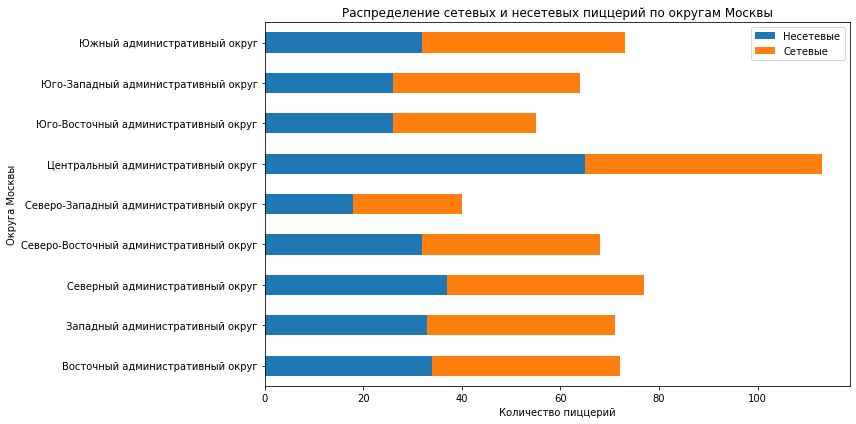

chain                                     0   1  Несетевые (%)  Сетевые (%)
district                                                                   
Восточный административный округ         34  38          47.22        52.78
Западный административный округ          33  38          46.48        53.52
Северный административный округ          37  40          48.05        51.95
Северо-Восточный административный округ  32  36          47.06        52.94
Северо-Западный административный округ   18  22          45.00        55.00
Центральный административный округ       65  48          57.52        42.48
Юго-Восточный административный округ     26  29          47.27        52.73
Юго-Западный административный округ      26  38          40.62        59.38
Южный административный округ             32  41          43.84        56.16


In [36]:
# Фильтруем только пиццерии
pizzerias = merged_data[merged_data['category'] == 'пиццерия']

# Группируем по округам и признаку сетевого заведения, чтобы найти распределение сетевых и несетевых пиццерий
district_chain_distribution = pizzerias.groupby(['district', 'chain']).size().unstack(fill_value=0)

# Добавляем процентное соотношение
percent_distribution = district_chain_distribution.div(district_chain_distribution.sum(axis=1), axis=0) * 100

# Строим график распределения пиццерий по округам и признаку сетевого заведения
district_chain_distribution.plot(kind='barh', stacked=True, figsize=(12, 6))
plt.title('Распределение сетевых и несетевых пиццерий по округам Москвы')
plt.xlabel('Количество пиццерий')
plt.ylabel('Округа Москвы')
plt.legend(['Несетевые', 'Сетевые'])
plt.tight_layout()
plt.show()

# Выводим информацию по всем округам, включая проценты
full_distribution = district_chain_distribution.copy()
full_distribution['Несетевые (%)'] = percent_distribution[0].round(2)
full_distribution['Сетевые (%)'] = percent_distribution[1].round(2)
print(full_distribution)

**Распределение сетевых и несетевых пиццерий по округам Москвы:**

Общие наблюдения:

- Большинство округов имеют примерно равное распределение между сетевыми и несетевыми пиццериями.
- Сетевые пиццерии чаще встречаются в густонаселенных районах с активной коммерческой деятельностью.

Округа с минимальным числом сетевых пиццерий:

- Северо-Западный административный округ: 18 сетевые пиццерии.
- Юго-Восточный административный округ: 26 сетевых пиццерий.
- Северо-Восточный и Восточный округа: 32-34 сетевых пиццерий.
- Западный административный округ: 33 сетевых пиццерий.

Вывод:
Северо-Западный и Юго-Восточный округа имеют меньше сетевых пиццерий, что может быть связано с меньшей плотностью населения или ориентированностью на местные заведения.
Равномерное распределение по остальным округам указывает на стабильный интерес к сетевым пиццериям.

---

### <font color='#7E60BF'> Задача 4. Зависимость среднего рейтинга от сетевого статуса и административного округа. </font>

Дополнительно можете изучить другие закономерности, которые покажутся вам интересными и важными.

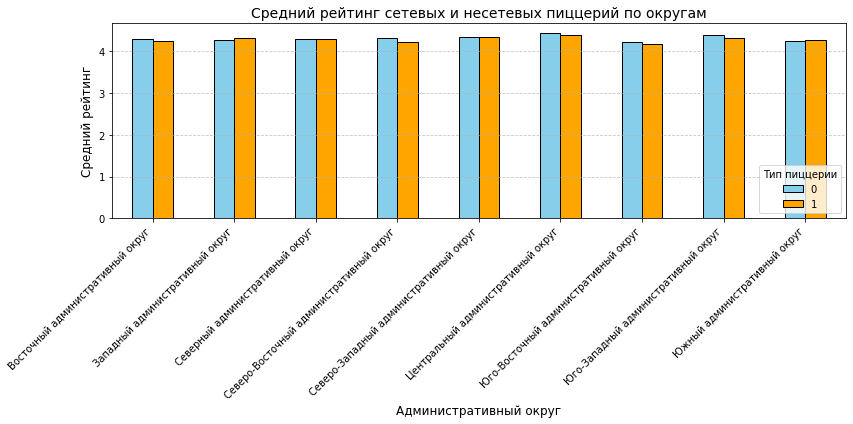

chain,0,1
district,,
Восточный административный округ,4.291176,4.250000
Западный административный округ,4.257576,4.315789
Северный административный округ,4.297297,4.287500
Северо-Восточный административный округ,4.306250,4.211111
Северо-Западный административный округ,4.344444,4.331818
Центральный административный округ,4.440000,4.372917
Юго-Восточный административный округ,4.211538,4.162069
Юго-Западный административный округ,4.392308,4.305263
Южный административный округ,4.237500,4.275610


In [37]:
# Изучим зависимость среднего рейтинга пиццерий от их сетевого статуса и административного округа
pizzeria_rating_analysis = (
    pizzerias.groupby(['district', 'chain'])['rating']
    .mean()
    .unstack()
    .sort_index()
)

# Визуализируем средние рейтинги сетевых и несетевых пиццерий по округам
pizzeria_rating_analysis.plot(
    kind='bar', figsize=(12, 6), color=['skyblue', 'orange'], edgecolor='black'
)
plt.title('Средний рейтинг сетевых и несетевых пиццерий по округам', fontsize=14)
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип пиццерии', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выводим данные для анализа
pizzeria_rating_analysis

**Зависимость среднего рейтинга пиццерий от сетевого статуса и административного округа:**

Общие наблюдения:

- Средний рейтинг сетевых и несетевых пиццерий по округам Москвы варьируется в пределах 4.16–4.44, что указывает на высокое качество обслуживания в данной категории заведений.
- Несетевые пиццерии чаще имеют немного более высокий рейтинг, что может быть связано с индивидуальным подходом.

Лучшие округа по рейтингам:

Центральный административный округ (ЦАО) лидирует с рейтингом:
- Несетевые: 4.44
- Сетевые: 4.37
Юго-Западный округ: также показывает высокие рейтинги для обоих типов заведений.

Округа с низкими рейтингами:

Юго-Восточный округ имеет самые низкие оценки:
- Несетевые: 4.21
- Сетевые: 4.16

Возможно, это связано с меньшей конкуренцией или более ограниченным выбором заведений.

Вывод:
Несетевые пиццерии имеют преимущество в рейтингах, особенно в ЦАО и Юго-Западном округе.
Сетевые пиццерии показывают стабильное качество с меньшими колебаниями, что может быть важным фактором для клиентов.

---

### <font color='#7E60BF'> Промежуточный вывод </font>

Попробуйте дать рекомендацию для открытия нового заведения. Это творческое задание: здесь нет правильного или неправильного ответа, но ваше решение должно быть чем-то обосновано. Например, можно сделать акцент на районах или улицах. Или дать характеристику типичной пиццерии.

**Рекомендация для открытия новой пиццерии:**

Целевой район:
Юго-Восточный административный округ:
- Рейтинг пиццерий в этом округе ниже среднего (4.16–4.21), что указывает на недостаток высококачественных заведений.
- Доля пиццерий в округе также ниже, что дает меньше конкуренции в данном сегменте.
Учитывая экономически активное население и доступные аренды, это идеальное место для открытия.

Формат заведения:

Размер и места:
- Рассчитать на 50–60 посадочных мест — это соответствует медианному значению по рынку и позволяет снизить расходы на площадь.

Кухня и сервис:
- Сделать акцент на быстрой доставке, так как округ густонаселен, а пицца — один из самых популярных продуктов для доставки.
- Предложить качественные и разнообразные начинки, возможно, с акцентом на локальные вкусы.

Ценовая политика:
- Установить средний чек в диапазоне 600–700 руб.:
Это соответствует медиане по пиццериям в Москве и привлекает как экономных, так и более платежеспособных клиентов.

Часы работы:
- Не стоит делать круглосуточное заведение: пиццерии редко востребованы ночью.
- Рекомендуемые часы: 10:00–23:00.

Дополнительная идея:
Разместить заведение недалеко от офисных центров или вузов, чтобы привлечь дневную аудиторию.
Для увеличения потока клиентов рассмотреть партнерство с популярными приложениями доставки, такими как Яндекс Еда или Delivery Club.

## <font color='#7E60BF'> Итоговый вывод и рекомендации. </font>

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

**Общий обзор проделанной работы**

В ходе проекта проведён исследовательский анализ рынка заведений общественного питания Москвы. Использовались данные о заведениях, включающие информацию о типах, ценах, рейтингах и расположении. 

Основные задачи включали:
- Выявление распределения заведений по административным округам Москвы.
- Оценку характеристик типового заведения.
- Анализ популярности сетевых и несетевых заведений.
- Поиск закономерностей в рейтингах и характеристиках заведений.

Особое внимание уделялось пиццериям как целевой категории, для которой было необходимо определить оптимальное место открытия нового заведения.

**Ответы на исследовательские вопросы и главные выводы**

Распределение заведений:

- Центральный округ (ЦАО) лидирует по количеству заведений, но доля пиццерий в нём низкая из-за высокой конкуренции.
- Наибольшая доля пиццерий наблюдается в Северо-Западном (9.78%) и Юго-Западном (9.03%) округах.

Типичная пиццерия:

- Среднее количество мест: 94.5, медианное: 55.
- Средний чек: 789 рублей, медианный: 600 рублей.
- Средний рейтинг: 4.30, что указывает на высокую удовлетворённость клиентов.

Сетевые и несетевые заведения:

- Сетевые пиццерии составляют 52.1% от общего числа.
- Несетевые заведения имеют немного более высокий рейтинг, особенно в ЦАО (4.44).

Зоны с потенциалом для роста:

- Юго-Восточный административный округ имеет меньшую конкуренцию и более низкие рейтинги пиццерий (4.16–4.21). Это говорит о возможности открытия качественного заведения в данном районе.

**Рекомендации на основе анализа данных**

Местоположение нового заведения:

- Целесообразно открыть пиццерию в Юго-Восточном округе. Низкий уровень конкуренции и средние рейтинги заведений создают возможность для привлечения клиентов за счёт улучшенного качества и сервиса.

Формат и концепция заведения:

- Количество посадочных мест: 50–60 для оптимизации затрат.
- Средний чек: 600–700 рублей, чтобы привлечь широкую аудиторию.
- Упор на доставку как важное направление в густонаселённых районах.

**Часы работы:**

- Оптимальное время: с 10:00 до 23:00, что соответствует пиковому спросу.

**Заключение**
Анализ показывает, что открытие пиццерии в Юго-Восточном округе с вышеуказанными характеристиками позволит занять нишу на рынке и привлечь значительное количество клиентов. Успех заведения будет зависеть от сочетания качественного обслуживания, конкурентоспособных цен и удобного расположения.